# Design Problem 

## ANN solutions


### 1 Problem definition

After thorough inspection of the contents in disc-benchmark-files, we have deduced the problem to two subproblems (deduced from example scripts), that closely relate to each other, and the materials discussed during the first 3 lectures. The main problem being "1-step-ahead prediction of the next state given past k input and output sequences.

As shown in the two example scripts (and discussed in the practical excercises) we will first train our model on predicting the next state using the provided dataset at each prediction set. After that we will validate our models performance by using each models observation predictions as input for its next prediction.

### 2 Neural Networks Solutions

##### 2.1 Approach

In this assignment, a NARX structure was used to model the system dynamics. NARX was chosen because in the dynamics of an unbalanced disk do not just depend on input voltage, but also on the measured angle. NARX uses past inputs and past outputs, and is relatively simple to implement.

The implementation of this NARX structure was done using a feedforward MultiLayer Perceptron(MLP) architecture. This is a basic neural network architecture in which the delayed input and output samples are provided as one input vector. The model is trained, optimized, evaluated and validated using the available data.

##### 2.2 Data Preparation
Here the data is prepared. The data is loaded, split into training and testing using a 80/20 split. From the training data 10% is used for validation. The data is normalized, fitted to the training data to avoid leakage. The 'old' mean and std are stored to later be used to undo the normalization on the output.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import pandas as df
import numpy as np

data = np.loadtxt("../gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv", delimiter=",", skiprows=1)
window_size = 15

# Prepare the data for training Window sized observations and the corresponding target values (1 step future output)
def prepare_windows(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])  # All columns except the last one
        y.append(data[i, -1])  # The last column is the target
    return np.array(X), np.array(y)

X, y = prepare_windows(data, window_size)

# Split the data into training and test using 80/20 split
def split_train_test(X, y, train_size=0.8):
    split_index = int(train_size * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_train_test(X, y)

# Create a validation set from the training data 10% of the training data will be used for validation
def split_train_val(X_train, y_train, validation_size=0.1):
    X_val, y_val = X_train[-int(validation_size * len(X_train)):], y_train[-int(validation_size * len(y_train)):]
    X_train, y_train = X_train[:-int(validation_size * len(X_train))], y_train[:-int(validation_size * len(y_train))]
    return X_train, y_train, X_val, y_val

X_train, y_train, X_val, y_val = split_train_val(X_train, y_train)

# Normalize the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

def scale_data(X_train, X_val, X_test, y_train, y_val, y_test):
# First we scale the training features and then we use the same scaler to transform the validation and test features. 
# This prevents data leakage.

    X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)  

    # For target value we need to scale using just the th mean and std of the training target values
    th_mean = scaler.mean_[-1]
    th_std = scaler.scale_[-1]

    y_train = (y_train - th_mean) / th_std
    y_val = (y_val - th_mean) / th_std
    y_test = (y_test - th_mean) / th_std

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = scale_data(X_train, X_val, X_test, y_train, y_val, y_test)

# Expose th_mean and th_std to the notebook scope for use in denormalization
th_mean = scaler.mean_[-1]
th_std = scaler.scale_[-1]

# Convert the data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


##### 2.3 Feedforward MLP definiton

Here the feedforward MLP is defined

In [4]:

#HEre I define the MLP class.
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, activation="tanh"):
        super().__init__()

        if activation == "tanh":
            activation_layer = nn.Tanh
        elif activation == "relu":
            activation_layer = nn.ReLU
        elif activation == "leaky_relu":
            activation_layer = nn.LeakyReLU
        elif activation == "elu":
            activation_layer = nn.ELU
        else:
            raise ValueError(f"Unknown activation function: {activation}")

        layers = []

        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(activation_layer())

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation_layer())

        layers.append(nn.Linear(hidden_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        x = inputs.reshape(inputs.shape[0], -1)
        return self.network(x).squeeze(-1)


##### 2.4 Optimization

Here the model is optimized using the training and validation data. The library Optuna is used to determine the optimal hyperparameters for the model.

In [5]:
import optuna

def objective(trial, model_type='RNN'):
    hidden_size = trial.suggest_int('hidden_size', 10, 100)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    num_layers = trial.suggest_int('num_layers', 1, 5)
    activation = trial.suggest_categorical("activation", ["tanh", "relu", "leaky_relu", "elu"])

    input_size = X_train.shape[1] * X_train.shape[2]

    model = MLP(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,activation=activation)

    num_epochs = 50

    return train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate, num_epochs, batch_size)

def train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate=1e-3, num_epochs=100, batch_size=64, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    best_val = float('inf')
    patience, no_improve = 50, 0

    for epoch in range(num_epochs):
        model.train()
        for i in range(0, len(X_train), batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        if val_loss < best_val:
            best_val = val_loss
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            break
        if verbose and (epoch % 100 == 0 or epoch == num_epochs - 1):
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss:.6f}, Best Val Loss: {best_val:.6f}')

    model.load_state_dict(best_state)
    return best_val

##### Find the optimal MLP

##### Train the model


In [ ]:
OPTIMIZATION_TRIALS = 100

# Run MLP optimization only if retraining is needed, otherwise just load the best model
def study_MLP():
    study_MLP = optuna.create_study(direction='minimize')
    study_MLP.optimize(lambda trial: objective(trial, model_type='MLP'), n_trials=OPTIMIZATION_TRIALS)
    print("Best hyperparameters MLP: ", study_MLP
    .best_params)
    input_size = X_train.shape[1] * X_train.shape[2]
    best_mlp = MLP(input_size=input_size, hidden_size=study_MLP.best_params['hidden_size'], num_layers=study_MLP.best_params['num_layers'], activation=study_MLP.best_params['activation'])
    train_advanced_network(best_mlp, X_train, y_train, X_val, y_val, learning_rate=study_MLP.best_params['learning_rate'], num_epochs=100, batch_size=study_MLP.best_params['batch_size'])
    torch.save(best_mlp.state_dict(), "best_mlp_model.pth")

    return best_mlp 

#best_mlp = study_MLP()
# Best hyperparameters MLP:  {'hidden_size': 68, 'learning_rate': 0.0004594214559485185, 'batch_size': 32, 'num_layers': 3, 'activation': 'leaky_relu'

Epoch 1/1000, Validation Loss: 0.017764, Best Val Loss: 0.017764
Epoch 101/1000, Validation Loss: 0.000919, Best Val Loss: 0.000143
Epoch 201/1000, Validation Loss: 0.000456, Best Val Loss: 0.000079


In [19]:
# Train the best models for 1000 epochs to get the best possible performance, then save them again
best_mlp = MLP(input_size=X_train.shape[1] * X_train.shape[2], hidden_size=68, num_layers=3, activation="leaky_relu")
best_mlp.load_state_dict(torch.load("best_mlp_model.pth"))
train_advanced_network(best_mlp, X_train, y_train, X_val, y_val, learning_rate=0.0004594214559485185, num_epochs=1000, batch_size=32,
  verbose=True)
torch.save(best_mlp.state_dict(), "best_mlp_model.pth")



Epoch 1/1000, Validation Loss: 0.001503, Best Val Loss: 0.001503


##### 2.5 Validation
Here the testing data is used to validate the effectiveness of the neural network.

MLP RMS:  0.004922888951212267 radians
MLP RMS:  0.2820607599160471 degrees
MLP NRMS: 0.9520429464606106 %


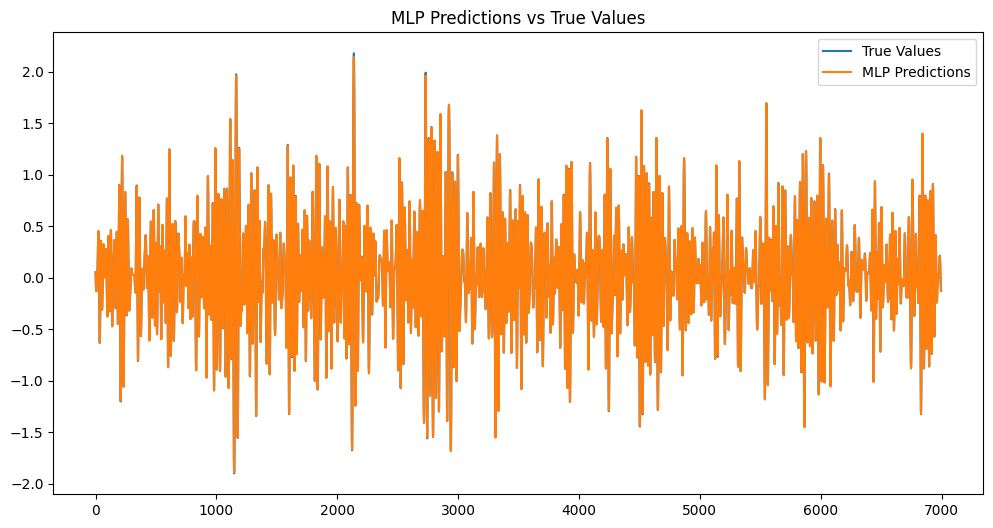

In [20]:
import matplotlib.pyplot as plt

best_mlp = MLP(input_size=X_train.shape[1] * X_train.shape[2], hidden_size=68, num_layers=3, activation="leaky_relu")
best_mlp.load_state_dict(torch.load("best_mlp_model.pth"))
best_mlp.eval()

# y_test may already be numpy (from a prior kernel run); handle both cases
y_test_np = y_test.numpy() * th_std + th_mean if hasattr(y_test, 'numpy') else y_test

with torch.no_grad():
    y_pred_mlp = best_mlp(X_test).numpy() * th_std + th_mean

print('MLP RMS: ',  np.mean((y_pred_mlp - y_test_np)**2)**0.5, 'radians')
print('MLP RMS: ',  np.mean((y_pred_mlp - y_test_np)**2)**0.5 / (2*np.pi) * 360, 'degrees')
print('MLP NRMS:', np.mean((y_pred_mlp - y_test_np)**2)**0.5 / y_test_np.std() * 100, '%')

plt.figure(figsize=(12, 6))
plt.plot(y_test_np, label='True Values')
plt.plot(y_pred_mlp, label='MLP Predictions')
plt.title('MLP Predictions vs True Values')
plt.legend()


### 3 Advanced Neural network Solutions


##### 3.1 Approach

As defined in practical excercise set 3, Problem 2: "A common approach for choosing neural network structures to solve a problem is by:

1. Looking up what others have used on similar problems and using that as a starting point.
2. Conducting a hyperparameter search using cross-validation around that starting point."

Hence rather than emperically testing a bunch of networks we have conducted research. Nonlinear system identification based on NARX network (IEEE) Treats NARX as an Recurrent neural network and shows it is able to "outperform standard neural networks such as FTDNN and Elman architectures". Neural network-based parametric system identification: a limitation we found in a source however adresses that "One limitation of the typical recurrent layer is that the time window of its inputs and outputs is required to be fixed during the training.". But as the training data contains a fixed window of 15 steps we will not have to overcome this limitation. Hence we shall resort to a simple RNN. It is however noted that regular RNN's fail to capture long term relationships effectively. Furthermore it is noted that LSTM's are able to do this better. Hence we shall also train an LSTM and assess whether the LSTM structure does a better job at catching long term dynamic relations than the RNN at a lookback of 15 steps.

The following cells will cover: 

- Data preparation
-  Model Definition
- Model Training
- Simulation evaluation

#### A) Data preparation

The exmaple prediction/simulation data shows 15th order lookback on input and outputs. Hence we will need to prepare the data such that our input shape becomes:
(N, 15, 2): N times: 15 samples for input u and output y.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import pandas as df
import numpy as np

data = np.loadtxt("../gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv", delimiter=",", skiprows=1)
window_size = 15

# Prepare the data for training Window sized observations and the corresponding target values (1 step future output)
def prepare_windows(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])  # All columns except the last one
        y.append(data[i, -1])  # The last column is the target
    return np.array(X), np.array(y)

X, y = prepare_windows(data, window_size)

# Split the data into training and test: sets 80% for training and 20% for testing
def split_train_test(X, y, train_size=0.8):
    split_index = int(train_size * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_train_test(X, y)

# Create a validation set from the training data 10% of the training data will be used for validation
def split_train_val(X_train, y_train, validation_size=0.1):
    X_val, y_val = X_train[-int(validation_size * len(X_train)):], y_train[-int(validation_size * len(y_train)):]
    X_train, y_train = X_train[:-int(validation_size * len(X_train))], y_train[:-int(validation_size * len(y_train))]
    return X_train, y_train, X_val, y_val

X_train, y_train, X_val, y_val = split_train_val(X_train, y_train)

# Normalize the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

def scale_data(X_train, X_val, X_test, y_train, y_val, y_test):
# First we scale the training features and then we use the same scaler to transform the validation and test features. 
# This prevents data leakage.

    X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)  

    # For target value we need to scale using just the th mean and std of the training target values
    th_mean = scaler.mean_[-1]
    th_std = scaler.scale_[-1]

    y_train = (y_train - th_mean) / th_std
    y_val = (y_val - th_mean) / th_std
    y_test = (y_test - th_mean) / th_std

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = scale_data(X_train, X_val, X_test, y_train, y_val, y_test)

# Expose th_mean and th_std to the notebook scope for use in denormalization
th_mean = scaler.mean_[-1]
th_std = scaler.scale_[-1]

# Convert the data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

##### B) Model definition

Here we shall perform model definition of both the LSTM followed by the recurrent Neural network.

In [21]:
class simple_lstm(nn.Module):
    def __init__(self, hidden_size, input_shape, num_layers=1, h2o_nodes=40):
        super(simple_lstm, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_shape[1]
        self.output_size = 1

        net = lambda n_in,n_out: nn.Sequential(nn.Linear(n_in,h2o_nodes),nn.Sigmoid(),nn.Linear(h2o_nodes,n_out))

        self.lstm = nn.LSTM(input_size=self.input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True).float()
        self.h2o = net(hidden_size + self.input_size, self.output_size).float()

    def forward(self, inputs):
        hiddens, _ = self.lstm(inputs)
        combined = torch.cat((hiddens, inputs), dim=2)
        h2o_input = combined.view(-1, self.hidden_size + self.input_size)
        y_predict = self.h2o(h2o_input).view(inputs.shape[0], inputs.shape[1])
        return y_predict[:, -1]
    

class simple_RNN(nn.Module):
    def __init__(self, hidden_size, input_shape, num_layers=1, h2o_nodes=40):
        super(simple_RNN, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_shape[1]
        self.output_size = 1

        net = lambda n_in,n_out: nn.Sequential(nn.Linear(n_in,h2o_nodes),nn.Sigmoid(),nn.Linear(h2o_nodes,n_out))

        self.h2h = net(self.input_size + self.hidden_size, hidden_size).float()
        self.h2o = net(hidden_size + self.input_size, self.output_size).float()

    def forward(self, inputs):
        hiddens = []
        h = torch.zeros(inputs.shape[0], self.hidden_size)
        for t in range(inputs.shape[1]):
            x = inputs[:, t, :]
            h = self.h2h(torch.cat((x, h), dim=1))
            hiddens.append(h)
        hiddens = torch.stack(hiddens, dim=1)
        combined = torch.cat((hiddens, inputs), dim=2)
        h2o_input = combined.view(-1, self.hidden_size + self.input_size)
        y_predict = self.h2o(h2o_input).view(inputs.shape[0], inputs.shape[1])
        return y_predict[:, -1]

#### C) Optimization

In [22]:
import optuna

def objective(trial, model_type='RNN'):
    hidden_size = trial.suggest_int('hidden_size', 10, 100)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    num_layers = trial.suggest_int('num_layers', 1, 5)
    h2o_nodes = trial.suggest_int('h2o_nodes', 10, 100)

    if model_type == 'LSTM':
        model = simple_lstm(hidden_size, X_train.shape[1:], num_layers=num_layers, h2o_nodes=h2o_nodes)
    else:
        model = simple_RNN(hidden_size, X_train.shape[1:], num_layers=num_layers, h2o_nodes=h2o_nodes)


    num_epochs = 50
    batch_size = 64


    return train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate, num_epochs, batch_size)

def train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate=1e-3, num_epochs=100, batch_size=64, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    best_val = float('inf')
    patience, no_improve = 50, 0

    for epoch in range(num_epochs):
        model.train()
        for i in range(0, len(X_train), batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        if val_loss < best_val:
            best_val = val_loss
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            break
        if verbose and (epoch % 100 == 0 or epoch == num_epochs - 1):
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss:.6f}, Best Val Loss: {best_val:.6f}')

    model.load_state_dict(best_state)
    return best_val


Find Optimal LSTM

In [23]:
OPTIMIZATION_TRIALS = 50

# Run LSTM optimization only if retraining is needed, otherwise just load two down here
def study_LSTM():
    study_LSTM = optuna.create_study(direction='minimize')
    study_LSTM.optimize(lambda trial: objective(trial, model_type='LSTM'), n_trials=OPTIMIZATION_TRIALS)
    print("Best hyperparameters LSTM: ", study_LSTM.best_params)

    best_lstm = simple_lstm(study_LSTM.best_params['hidden_size'], X_train.shape[1:], num_layers=study_LSTM.best_params['num_layers'], h2o_nodes=study_LSTM.best_params['h2o_nodes'])
    train_advanced_network(best_lstm, X_train, y_train, X_val, y_val, learning_rate=study_LSTM.best_params['learning_rate'], num_epochs=100, batch_size=study_LSTM.best_params['batch_size'])
    torch.save(best_lstm.state_dict(), "best_lstm_model.pth")

    return best_lstm

#best_lstm = study_LSTM()
# Best hyperparameters LSTM:  {'hidden_size': 43, 'learning_rate': 0.0012923160599238159, 'batch_size': 128, 'num_layers': 2, 'h2o_nodes': 80}


Find Optimal RNN

In [24]:
# RUN ONLY IF RETRAINING IS NEEDED
def study_RNN():

    study_RNN = optuna.create_study(direction='minimize')
    study_RNN.optimize(lambda trial: objective(trial, model_type='RNN'), n_trials=OPTIMIZATION_TRIALS)
    print("Best hyperparameters RNN: ", study_RNN.best_params)

    best_rnn = simple_RNN(study_RNN.best_params['hidden_size'], X_train.shape[1:], num_layers=study_RNN.best_params['num_layers'], h2o_nodes=study_RNN.best_params['h2o_nodes'])
    train_advanced_network(best_rnn, X_train, y_train, X_val, y_val, learning_rate=study_RNN.best_params['learning_rate'], num_epochs=100, batch_size=study_RNN.best_params['batch_size'])
    torch.save(best_rnn.state_dict(), "best_rnn_model.pth")

    return best_rnn

#best_rnn = study_RNN()
# Best hyperparameters LSTM:  {'Best hyperparameters RNN:  {'hidden_size': 59, 'learning_rate': 0.0016083872080996568, 'batch_size': 128, 'num_layers': 1, 'h2o_nodes': 38}': 43, 'learning_rate': 0.0012923160599238159, 'batch_size': 128, 'num_layers': 2, 'h2o_nodes': 80}


In [25]:
# Train the best models for 1000 epochs to get the best possible performance, then save them again
best_lstm = simple_lstm(hidden_size=43, input_shape=X_train.shape[1:], num_layers=2, h2o_nodes=80)
best_lstm.load_state_dict(torch.load("best_lstm_model.pth"))
train_advanced_network(best_lstm, X_train, y_train, X_val, y_val, learning_rate=0.0016083872080996568, num_epochs=1000, batch_size=128,
  verbose=True)
torch.save(best_lstm.state_dict(), "best_lstm_model.pth")

best_rnn = simple_RNN(hidden_size=59, input_shape=X_train.shape[1:], num_layers=1, h2o_nodes=38)
best_rnn.load_state_dict(torch.load("best_rnn_model.pth"))
train_advanced_network(best_rnn, X_train, y_train, X_val, y_val, learning_rate=0.0012923160599238159, num_epochs=1000, batch_size=128,
verbose=True)
torch.save(best_rnn.state_dict(), "best_rnn_model.pth")

Epoch 1/1000, Validation Loss: 0.000165, Best Val Loss: 0.000165
Epoch 101/1000, Validation Loss: 0.000156, Best Val Loss: 0.000059
Epoch 1/1000, Validation Loss: 0.000172, Best Val Loss: 0.000172


#### D) Validation

LSTM RMS:  0.003862954191909354 radians
LSTM RMS:  0.22133097164877544 degrees
LSTM NRMS: 0.747060989462724 %

RNN RMS:   0.007146675716918269 radians
RNN RMS:   0.4094743561280486 degrees
RNN NRMS:  1.3821035319632562 %


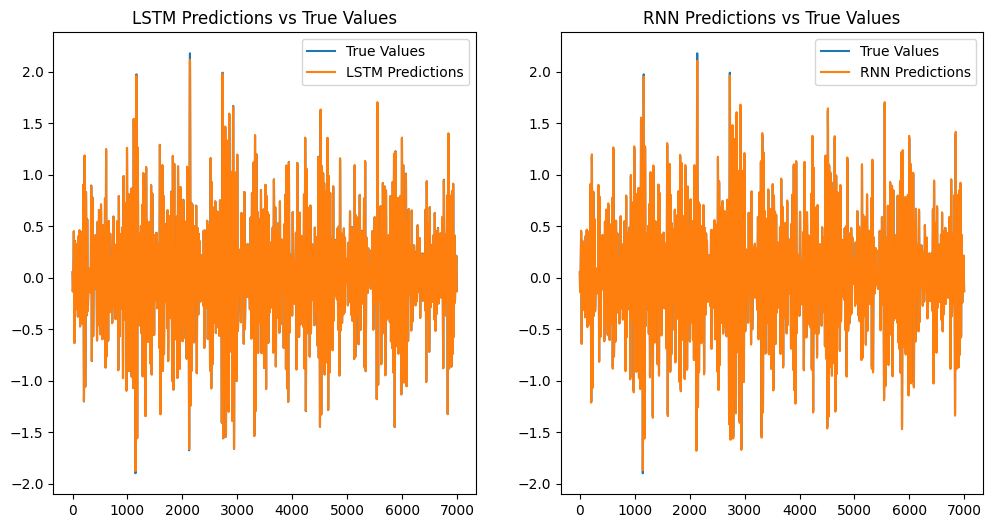

In [26]:
import matplotlib.pyplot as plt

best_lstm = simple_lstm(hidden_size=43, input_shape=X_train.shape[1:], num_layers=2, h2o_nodes=80)
best_lstm.load_state_dict(torch.load("best_lstm_model.pth"))
best_lstm.eval()

best_rnn = simple_RNN(hidden_size=59, input_shape=X_train.shape[1:], num_layers=1, h2o_nodes=38)
best_rnn.load_state_dict(torch.load("best_rnn_model.pth"))
best_rnn.eval()

# y_test may already be numpy (from a prior kernel run); handle both cases
y_test_np = y_test.numpy() * th_std + th_mean if hasattr(y_test, 'numpy') else y_test

with torch.no_grad():
    y_pred_lstm = best_lstm(X_test).numpy() * th_std + th_mean
    y_pred_rnn  = best_rnn(X_test).numpy()  * th_std + th_mean

print('LSTM RMS: ',  np.mean((y_pred_lstm - y_test_np)**2)**0.5, 'radians')
print('LSTM RMS: ',  np.mean((y_pred_lstm - y_test_np)**2)**0.5 / (2*np.pi) * 360, 'degrees')
print('LSTM NRMS:', np.mean((y_pred_lstm - y_test_np)**2)**0.5 / y_test_np.std() * 100, '%')
print('\n====================================================================')
print('RNN RMS:  ', np.mean((y_pred_rnn - y_test_np)**2)**0.5, 'radians')
print('RNN RMS:  ', np.mean((y_pred_rnn - y_test_np)**2)**0.5 / (2*np.pi) * 360, 'degrees')
print('RNN NRMS: ', np.mean((y_pred_rnn - y_test_np)**2)**0.5 / y_test_np.std() * 100, '%')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(y_test_np, label='True Values')
plt.plot(y_pred_lstm, label='LSTM Predictions')
plt.title('LSTM Predictions vs True Values')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(y_test_np, label='True Values')
plt.plot(y_pred_rnn, label='RNN Predictions')
plt.title('RNN Predictions vs True Values')
plt.legend()
plt.show()

According to our study the RNN performs a little bit better than the lstm given the project. Hence we shall do the submission for advanced networks using the best trained RNN model fam.

#### E) Fill in solutions

In [11]:
import numpy as np
import torch
from pathlib import Path

_dir = Path('../gym-unbalanced-disk/disc-benchmark-files')

# ── Prediction task ──────────────────────────────────────────────────────────
pred_data = np.load(_dir / 'hidden-test-prediction-submission-file.npz')
upast_pred  = pred_data['upast']   # (645, 15)
thpast_pred = pred_data['thpast']  # (645, 15)
y_pred     = pred_data['thnow']   # (645,)
X_pred = np.stack([upast_pred, thpast_pred], axis=2)  # (645, 30)
X_pred = scaler.transform(X_pred.reshape(-1, X_pred.shape[-1])).reshape(X_pred.shape)  # Scale using the same scaler as before    
X_pred = torch.tensor(X_pred, dtype=torch.float32)

with torch.no_grad():
    Ypredict = best_rnn(X_pred).cpu().numpy() * th_std + th_mean  # Denormalize the predictions

assert len(Ypredict)==len(upast_pred), 'number of samples changed!!'
np.savez('RNN-predictions.npz', upast=upast_pred, thpast=thpast_pred, thnow=Ypredict)